# 1. Indexing, slicing, and shapes: selecting the intended observations

Learn to locate array values, select rows and columns, preserve observation identity, and distinguish views from independent copies. Prerequisite: [NumPy basics](../../../01_Python_Foundations/13_numpy_basics.ipynb). You will work with a synthetic table of three packages, with mass in kilograms and travel distance in kilometers. This lesson teaches data selection rather than a predictive algorithm. Allow two hours and attempt each selection on paper before executing it.

## 2. What problem does this solve?

A machine learning table contains observations and features. Selecting the wrong axis can silently change which values belong to which observations. A model may still run if the resulting dimensions happen to fit, even when the feature and target rows are misaligned. Array shapes tell us how many entries lie along each axis; row identifiers tell us what those entries mean.

Our task is to select heavy packages and keep their delivery times aligned. We also need to extract one feature as a vector or as a one-column table depending on the receiving function. These are different shapes with different broadcasting behavior, even when they contain the same numbers.

## 3. Intuition and analogy

Think of a two-dimensional array as a grid with street addresses. The first coordinate identifies the row, and the second identifies the column. Python starts numbering at zero. To reach row three, column two in ordinary counting, write indices 2 and 1.

A slice resembles a marked stretch of road: its start is included and its stop is excluded. A view resembles looking at the same grid through a smaller window. Editing through that window may change the original grid. A copy is a separate grid whose later edits do not affect the source.

## 4. Terminology

An **axis** is a dimension along which values are arranged. A table's axis 0 identifies rows and axis 1 identifies columns. Its **shape** is a tuple containing the length of each axis. Its **ndim** is the number of axes; its **size** counts all elements. An **index** selects a position. A **slice** selects a sequence of positions. A **Boolean mask** selects positions where its entries are true.

Basic indexing includes integers and slices; array-based **advanced indexing** includes integer index arrays and Boolean masks. Basic slicing typically returns a view; advanced indexing returns a copy. Negative indices count from the end. `None` in an indexing expression inserts a new axis; it is not a missing measurement in that context.

## 5. Mathematical foundations

Represent three observations and two features as

$$X=\begin{bmatrix}1&10\\2&20\\4&40\end{bmatrix},\qquad y=\begin{bmatrix}5\\7\\9\end{bmatrix}.$$

$X$ is a numerical feature table with shape $(3,2)$: column 0 is mass in kilograms and column 1 is distance in kilometers. $y$ is a target vector with shape $(3,)$ containing delivery times in hours. The entry $X_{i,j}$ uses row index $i$ and column index $j$. In this lesson mathematical indices also start at zero to match code.

Define a mask $m_i=[X_{i,0}\geq2]$. The brackets mean the statement becomes true or false. The mask has shape $(3,)$ and values false, true, true. Applying the same mask to $X$, $y$, and identifiers selects matching observations. There are $k=2$ selected rows, so the selected feature shape is $(2,2)$ and target shape is $(2,)$.

## 6. Hand-calculated example

The entry at `[2, 1]` is 40 kilometers. Rows `[0:2]` contain the first two observations because stop 2 is excluded. Column `[1]` in mathematical prose means the distance feature; in NumPy `X[:, 1]` selects that column from all rows and produces `[10,20,40]` with shape `(3,)`.

Mass at least two kilograms selects package IDs 102 and 103. Their delivery times are 7 and 9 hours, with mean $(7+9)/2=8$ hours. Selecting those rows from the features but taking the first two targets would instead pair them with 5 and 7: the same target length, wrong observation meaning.

## 7. Selection from scratch

Before using array indexing, implement selection with a loop. `enumerate` provides both the position and its row; the position retrieves the matching target and identifier. Do not filter each field independently using unrelated rules. Every record's associated fields must move together.

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
rows = [[1.0, 10.0], [2.0, 20.0], [4.0, 40.0]]
targets = [5.0, 7.0, 9.0]
ids = [101, 102, 103]
selected_rows, selected_targets, selected_ids = [], [], []
for position, row in enumerate(rows):
    if row[0] >= 2.0:
        selected_rows.append(row.copy())
        selected_targets.append(targets[position])
        selected_ids.append(ids[position])
assert selected_ids == [102, 103]
assert selected_targets == [7.0, 9.0]
assert sum(selected_targets) / len(selected_targets) == 8.0
print('Manual selection:', selected_ids, selected_rows, selected_targets)

Manual selection: [102, 103] [[2.0, 20.0], [4.0, 40.0]] [7.0, 9.0]


## 8. Inspecting intermediate shapes

In [3]:
import numpy as np
X = np.array(rows)
y = np.array(targets)
row_ids = np.array(ids)
assert X.shape == (3, 2) and X.ndim == 2 and X.size == 6
assert X[2, 1] == 40.0
np.testing.assert_array_equal(X[0:2], rows[:2])
assert X[-1, 0] == 4.0
vector = X[:, 1]
column = X[:, 1:2]
assert vector.shape == (3,)
assert column.shape == (3, 1)
assert X[1].shape == (2,)
assert X[1:2].shape == (1, 2)
for name, value in [('table', X), ('row', X[1]), ('vector', vector), ('column', column)]:
    print(name, value.shape, value.tolist())

table (3, 2) [[1.0, 10.0], [2.0, 20.0], [4.0, 40.0]]
row (2,) [2.0, 20.0]
vector (3,) [10.0, 20.0, 40.0]
column (3, 1) [[10.0], [20.0], [40.0]]


An integer selection removes the selected axis; a slice preserves it. This distinction explains the row and column examples above. A zero-dimensional result such as `X[2,1]` is a scalar, not a one-element row table.

## 9. NumPy implementation

In [4]:
mask = X[:, 0] >= 2.0
assert mask.shape == (len(X),)
X_selected, y_selected, ids_selected = X[mask], y[mask], row_ids[mask]
np.testing.assert_array_equal(X_selected, selected_rows)
np.testing.assert_array_equal(y_selected, selected_targets)
np.testing.assert_array_equal(ids_selected, selected_ids)
order = np.array([2, 0, 1])
X_reordered, y_reordered, ids_reordered = X[order], y[order], row_ids[order]
assert ids_reordered.tolist() == [103, 101, 102]
assert y_reordered.tolist() == [9.0, 5.0, 7.0]
print('Aligned selection:', ids_selected, y_selected)

Aligned selection: [102 103] [7. 9.]


The comparisons produce the mask element by element. The same row operation is applied to every aligned field. For two specific row and column sets, `X[[0,2],[0,1]]` selects paired coordinates `(0,0)` and `(2,1)`, not their rectangular cross product. Use `np.ix_` when you want every combination.

In [5]:
paired = X[[0, 2], [0, 1]]
rectangle = X[np.ix_([0, 2], [0, 1])]
np.testing.assert_array_equal(paired, [1.0, 40.0])
np.testing.assert_array_equal(rectangle, [[1.0, 10.0], [4.0, 40.0]])
assert paired.shape == (2,) and rectangle.shape == (2, 2)

## 10. Visualization

Color the selected observations on the original mass-distance plane. This makes the row rule visible. Mass and distance use different units; neither axis is a row number. The chart demonstrates a synthetic selection rule, not a physical relationship inferred from real packages.

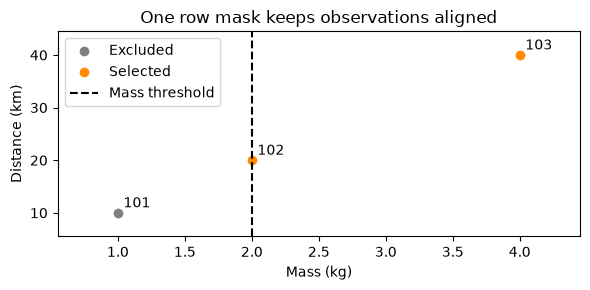

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(X[~mask, 0], X[~mask, 1], label='Excluded', color='gray')
ax.scatter(X[mask, 0], X[mask, 1], label='Selected', color='darkorange')
for ident, row in zip(row_ids, X):
    ax.annotate(str(ident), row, xytext=(4, 4), textcoords='offset points')
ax.axvline(2, linestyle='--', color='black', label='Mass threshold')
ax.set(xlabel='Mass (kg)', ylabel='Distance (km)', title='One row mask keeps observations aligned')
ax.margins(x=0.15, y=0.15)
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

## 11. Experiment: views and copies

The original feature table should remain unchanged during inspection. Work on a separate demonstration array when testing view behavior. `np.shares_memory` checks whether two arrays overlap in storage; value equality alone cannot tell you that. Advanced indexing produces an independent array even when you select all rows.

In [7]:
demo = X.copy()
window = demo[:2, :1]
assert np.shares_memory(demo, window)
window[0, 0] = 99.0
assert demo[0, 0] == 99.0
independent = demo[[0, 1], :1]
assert not np.shares_memory(demo, independent)
independent[0, 0] = -5.0
assert demo[0, 0] == 99.0
np.testing.assert_array_equal(X, rows)
print('View edit reaches its source; advanced-index copy edit does not.')

View edit reaches its source; advanced-index copy edit does not.


## 12. Selection choices

Indices, thresholds, and whether to preserve an axis are programming choices, not learned model parameters. In a real modeling workflow, a filtering threshold chosen after inspecting test outcomes can nevertheless leak evaluation information. Specify selection rules using domain knowledge or training/validation data and document which observations they remove.

## 13. Evaluation

Verify shapes, exact selected identifiers, target alignment, numerical results, and mutation behavior. A shape assertion catches structural problems; an ID assertion catches semantic mistakes that shapes cannot. A selection with zero rows is valid NumPy behavior, but a downstream mean or estimator may require nonempty input. Check that condition explicitly rather than assuming a mask selects something.

In [8]:
empty_mask = X[:, 0] > 100
assert X[empty_mask].shape == (0, 2)
assert y[empty_mask].shape == (0,)
np.testing.assert_array_equal(X_selected[:, 0], [2.0, 4.0])
assert len(X_selected) == len(y_selected) == len(ids_selected)
assert np.mean(y_selected) == 8.0

## 14. Assumptions and limitations

This array has homogeneous numerical values and known column meanings. NumPy does not attach column units or row identifiers automatically. Store those separately or use a labeled table when that makes alignment clearer. A matching length is necessary for aligned arrays but is not sufficient. We use small arrays; large advanced-index copies may consume substantial additional memory.

## 15. Common mistakes and debugging

Avoid treating an excluded slice endpoint as included. Print the shape immediately after a selection when dimensions surprise you. `X[0:2]` selects rows, whereas `X[:,0:2]` selects columns across all rows. Use parentheses and elementwise `&` for combined array conditions, such as `(X[:,0]>=2) & (X[:,1]<40)`; Python's `and` does not combine arrays elementwise.

Do not assume a slice is an independent copy. Call `.copy()` when you intend to edit separately. Do not apply a row permutation to features without applying it to targets and IDs. A reshape changes organization, not observation meaning; verify that the new arrangement matches the data contract.

## 16. Alternatives

Python lists work well for a tiny manually selected example. NumPy offers fast homogeneous array operations and explicit shapes. pandas provides named columns and index alignment, which helps with tabular meaning but introduces its own label-versus-position distinctions. A dataset object can store features and targets together. Whichever representation you choose, preserve identity and explain axis meaning.

## 17. Exercises

- **Beginner:** Predict `X[1,0]`, `X[-1,1]`, and the shape of `X[:1]`.
- **Beginner:** Select distances as a vector and as a one-column table. Explain the difference.
- **Beginner:** Calculate the selected IDs and target mean for mass strictly greater than two.
- **Intermediate:** Reverse observation order while preserving features, targets, and IDs together.
- **Intermediate:** Select rows 0 and 2 and only column 1 as a rectangular table without dropping its feature axis.
- **Challenge:** Filter mass at least two and distance below forty; edit an independent selected copy and prove that source data and target alignment remain correct.

## 18. Detailed solutions

The first entries are 2 kilograms and 40 kilometers; `X[:1]` has shape `(1,2)`. `X[:,1]` is shape `(3,)`; `X[:,1:2]` is shape `(3,1)`. Strictly greater than two selects ID 103 alone, with target 9 hours. Reversal uses the same `[::-1]` row slice on all fields. The challenge selects only ID 102, because ID 103's distance is not below forty.

In [9]:
assert X[1, 0] == 2 and X[-1, 1] == 40 and X[:1].shape == (1, 2)
assert X[:, 1].shape == (3,) and X[:, 1:2].shape == (3, 1)
strict = X[:, 0] > 2
assert row_ids[strict].tolist() == [103] and y[strict].mean() == 9
reverse_X, reverse_y, reverse_ids = X[::-1], y[::-1], row_ids[::-1]
assert reverse_ids.tolist() == [103, 102, 101]
assert reverse_y.tolist() == [9, 7, 5]
np.testing.assert_array_equal(reverse_X[0], [4, 40])
distance_table = X[np.ix_([0, 2], [1])]
assert distance_table.shape == (2, 1)
np.testing.assert_array_equal(distance_table, [[10], [40]])
combined = (X[:, 0] >= 2) & (X[:, 1] < 40)
selected_copy = X[combined].copy()
selected_copy[0, 0] = 999
assert row_ids[combined].tolist() == [102] and y[combined].tolist() == [7]
np.testing.assert_array_equal(X, rows)
print('Selection exercises passed with observation identity preserved.')

Selection exercises passed with observation identity preserved.


## 19. Knowledge check

**What does shape describe?** The length of each axis, such as three observations and two features.

**Is a slice stop included?** No; `[0:2]` selects positions zero and one.

**Why preserve identifiers?** They reveal wrong pairings that equal lengths can hide.

**Can editing a slice change the source?** Yes, because basic slices commonly share memory.

**What does an empty mask selection return?** A correctly shaped array with zero selected rows, not necessarily an error.

## 20. Interview preparation

**How do integer and slice column selections differ?** An integer removes that axis; a slice preserves it, affecting downstream shapes.

**Why is target alignment important?** Training on incorrectly paired observations teaches a relationship that was never in the data.

**What does advanced indexing return?** An independent copy, unlike basic slicing's usual view behavior.

**How do you select a rectangular row-column subset?** Use `np.ix_` or equivalent successive indexing rather than paired coordinate selection.

**How would you investigate a silent selection defect?** Inspect shapes, selected IDs, a hand-worked row, and whether edits share memory.

## 21. Summary and next steps

Select positions deliberately, preserve axes when required, and move aligned fields together. Shape checks and identity checks answer different questions. Continue to [vectorization and broadcasting](../../../01_Python_Foundations/15_vectorization_and_broadcasting.ipynb), where these shape distinctions determine how whole-array arithmetic works.